# 기공(Porosity) YOLOv8-seg 결함 탐지 — 학습 파이프라인

**담당**: YOLOv8-seg 결함 탐지 학습
**산출물**: `artifacts/porosity_yolov8seg/` (best.pt + thresholds.json + model_config.json)
→ 대시보드/API 오케스트레이션은 `porosity.detector.PorosityDetector` 하나만 임포트하면 된다.

---

## ⚠️ 시작 전 반드시 읽을 것 — 이 데이터셋의 라벨 누수

`metadata.csv` 전수 집계 결과:

| class | 총 | 1280×720 | 비율 |
|---|---|---|---|
| 기공 | 24,345 | 24,345 | **1.000** |
| 균열 | 2,054 | 2,054 | 1.000 |
| 융합불량 | 2,928 | 2,928 | 1.000 |
| 슬래그혼입 | 1,030 | 1,030 | 1.000 |
| 정상 | 23,696 | 2,090 | **0.088** |

결함 이미지는 전량 1280×720 크롭인데, 정상은 91%가 원본 RT 필름 파노라마(평균 3165×917, AR 최대 10.7)다.
**그대로 학습하면 모델이 "가로로 긴 이미지 = 정상"을 외운다.** mAP는 0.99가 나오고 현장에서는 무용지물이 된다.

**본 파이프라인의 대응**: 음성(정상) 샘플을 크기 정합된 소스에서만 취한다.
1. 이미 1280×720인 정상 2,090장 (train 1,850 / val 240)
2. 정상 파노라마 20,933장에서 **네이티브 스케일 1280×720 랜덤 크롭** 생성

→ 양성·음성이 픽셀 통계상 구분 불가능해지고, 모델이 진짜 기공 텍스처를 학습한다.

부수 결정:
- 양성은 `annotation_case == 'porosity'` 순수 기공만 사용(다중결함 136장 제외 = `is_crowd==1`)
- 정상 이미지도 라벨 JSON에 '정상' 어노테이션이 1개 있지만 **빈 .txt(background)로 변환**한다.
  class 0으로 넣으면 학습이 붕괴된다.


## 0. 환경 설정

`src/porosity/` 의 모듈을 임포트해서 쓴다. 노트북에 로직을 직접 쓰지 않는 이유는
git 병합 시 노트북이 아니라 **`.py` 모듈이 그대로 패키지로 들어가야** 하기 때문이다.

In [1]:
# 최초 1회
# %pip install -q ultralytics pandas pillow tqdm scikit-learn matplotlib pyyaml

In [ ]:
import os, sys, json, warnings
from pathlib import Path

# --- 경로: 본인 환경에 맞게 이 두 줄만 수정 ---
os.environ["WELDSCAN_ROOT"] = r"C:\Users\user\weldscan\weld_db"   # metadata.csv / images / labels
os.environ["WELDSCAN_WORK"] = r"C:\Users\user\weldscan\work"      # 산출물

# --- src/porosity 탐색: 노트북을 어디서 실행하든 프로젝트 루트를 찾는다 ---
# 기대 구조:  <project_root>/{src/porosity/, notebooks/이 노트북}
def _find_src(start: Path) -> Path:
    for base in [start, *start.parents]:
        cand = base / "src"
        if (cand / "porosity" / "__init__.py").exists():
            return cand
    raise FileNotFoundError(
        "src/porosity 를 찾을 수 없습니다.\n"
        f"  탐색 시작 위치: {start}\n"
        "  weldscan_porosity/ 폴더 전체(구조: src/porosity/, notebooks/)를 "
        "함께 받았는지, 이 노트북이 그 안의 notebooks/ 폴더에 있는지 확인하세요.\n"
        "  파일을 낱개로 다운로드했다면 src/porosity/*.py 를 이 노트북과 같은 "
        "부모 폴더 밑 src/porosity/ 경로에 그대로 배치해야 합니다."
    )

SRC = _find_src(Path.cwd())
sys.path.insert(0, str(SRC.resolve()))
print("src 경로 확인:", SRC.resolve())

%load_ext autoreload
%autoreload 2

import pandas as pd, numpy as np
import porosity
from porosity import config as cfg, data_prep as D, label_io as L, evaluate as E

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)
warnings.filterwarnings("ignore", category=UserWarning)

cfg.PATHS.ensure()
print("porosity", porosity.__version__, "| schema", cfg.SCHEMA_VERSION)
print("raw :", cfg.PATHS.raw_root, "->", cfg.PATHS.raw_root.exists())
print("work:", cfg.PATHS.work_root)

src 경로 확인: C:\Users\user\weldscan\weldscan_porosity\src
porosity 1.0.0 | schema 1.0
raw : C:\Users\user\weldscan\weld_db -> True
work: C:\Users\user\weldscan\work


In [3]:
import torch
print("torch", torch.__version__, "| cuda", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
if not torch.cuda.is_available():
    cfg.TRAIN.device = "cpu"; cfg.TRAIN.batch = 2; cfg.TRAIN.amp = False
    print("!! CPU 모드 - 전량 학습은 비현실적. 아래 QUICK_RUN을 켜고 파이프라인 검증만 할 것.")

torch 2.12.1+cu130 | cuda True | NVIDIA GeForce RTX 5070


In [3]:
   cfg.TRAIN.workers = 0
   print("workers 설정 확인:", cfg.TRAIN.workers)

workers 설정 확인: 0


## 1. 메타데이터 로드 & 누수 진단

`load_metadata()`는 필수 컬럼 존재와 `label_id` 유일성을 검증하고,
`is_tile` / `croppable` / `aspect` 파생 컬럼을 붙인다.

In [4]:
df = D.load_metadata()
print(df.shape)
display(df.head(3))
print("\n--- 누수 진단: tile_ratio가 클래스마다 다르면 크기가 곧 라벨이다 ---")
display(D.leakage_report(df))

(54053, 17)


,label_id,filename,image_path,label_path,type,material,class,width,height,is_crowd,annotation_case,num_annotations,split,image_exists,is_tile,croppable,aspect
0,14493416,RT_ST_00_14493416.jpg,images/train/RT_ST_00_14493416.jpg,labels/train/RT_ST_00_14493416.json,RT,ST,정상,3481,943,0,normal,1,train,True,False,True,3.691410
1,14493417,RT_ST_00_14493417.jpg,images/train/RT_ST_00_14493417.jpg,labels/train/RT_ST_00_14493417.json,RT,ST,정상,5019,1191,0,normal,1,train,True,False,True,4.214106
2,14493418,RT_ST_00_14493418.jpg,images/train/RT_ST_00_14493418.jpg,labels/train/RT_ST_00_14493418.json,RT,ST,정상,3377,1294,0,normal,1,train,True,False,True,2.609737



--- 누수 진단: tile_ratio가 클래스마다 다르면 크기가 곧 라벨이다 ---


,n,n_tile,w_mean,h_mean,ar_mean,tile_ratio
class,,,,,,
기공,24345,24345,1280.000000,720.000000,1.777778,1.000
정상,23696,2090,3165.144455,917.660871,3.464068,0.088
융합불량,2928,2928,1280.000000,720.000000,1.777778,1.000
균열,2054,2054,1280.000000,720.000000,1.777778,1.000
슬래그혼입,1030,1030,1280.000000,720.000000,1.777778,1.000


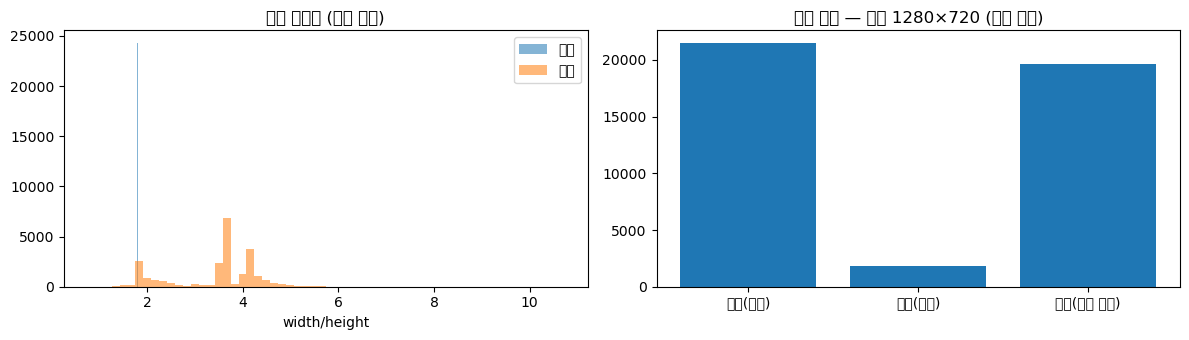

train  양성 21,534 / 음성 21,534


In [5]:
# 누수를 눈으로: 종횡비 분포
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
for k, sub in df[df["class"].isin(["기공", "정상"])].groupby("class"):
    ax[0].hist(sub["aspect"], bins=60, alpha=.55, label=k)
ax[0].set_title("원본 종횡비 (누수 있음)"); ax[0].set_xlabel("width/height"); ax[0].legend()

# 본 파이프라인이 실제로 학습에 쓸 서브셋
pos_tr = D.select_positives(df, "train")
neg_t, neg_p = D.select_negatives(df, "train", len(pos_tr))
ax[1].bar(["기공(타일)", "정상(타일)", "정상(파노 크롭)"],
          [len(pos_tr), len(neg_t), int(neg_p["n_crops"].sum()) if len(neg_p) else 0])
ax[1].set_title("학습 구성 — 전부 1280×720 (누수 제거)")
plt.tight_layout(); plt.show()

print(f"train  양성 {len(pos_tr):,} / 음성 {len(neg_t) + int(neg_p['n_crops'].sum()):,}")

## 2. 라벨 JSON 스키마 정찰 — **건너뛰지 말 것**

AI Hub 라벨 JSON의 정확한 구조를 나는 모른다. `label_io`는 폴리곤/bbox/원 키를
**재귀 탐색으로 자동 검출**하도록 만들었지만, 실제 파일로 한 번 확인해야 안전하다.

아래 셀에서 `matched` 수가 `num_annotations`와 맞는지 확인하라. 안 맞으면
`porosity/config.py`의 `POROSITY_ALIASES` 또는 `label_io.POLY_KEYS`에 실제 키 이름을 추가하면 된다.

In [6]:
# 기공 이미지 1장의 라벨 구조를 통째로 출력
s = df[df["annotation_case"] == "porosity"].iloc[0]
obj = L.inspect_schema(cfg.PATHS.raw_root / s.label_path)
print("\n등장 키 전체:", sorted(L.collect_keys(obj)))
print("\nmetadata num_annotations =", s.num_annotations)

=== RT_ST_02_14517430.json ===
dict(4 keys)
  'info':
    dict(3 keys)
      'id': int = 14517430
      'type': str = 'RT'
      'material': str = 'ST'
  'image_data':
    dict(5 keys)
      'file_name': str = 'RT_ST_02_14517430'
      'format': str = 'jpg'
      'information': str = '기공'
      'width': int = 1280
      'height': int = 720
  'meta':
    dict(3 keys)
      'is_crowd': int = 0
      'annotation_case':
        list(len=1)
          ...
      'total_case':
        list(len=1)
          ...
  'annotations':
    list(len=1)
      dict(4 keys)
        'tool': str = 'polygon'
        'coordinate':
          ...
        'class': str = 'defect'
        'case': str = 'porosity'

등장 키 전체: ['annotation_case', 'annotations', 'case', 'class', 'coordinate', 'file_name', 'format', 'height', 'id', 'image_data', 'info', 'information', 'is_crowd', 'material', 'meta', 'tool', 'total_case', 'type', 'width', 'x', 'y']

metadata num_annotations = 1


In [7]:
# 정상 이미지 라벨도 확인 — '정상' 어노테이션이 배제되는지가 핵심
sn = df[df["annotation_case"] == "normal"].iloc[0]
_ = L.inspect_schema(cfg.PATHS.raw_root / sn.label_path)

=== RT_ST_00_14493416.json ===
dict(4 keys)
  'info':
    dict(3 keys)
      'id': int = 14493416
      'type': str = 'RT'
      'material': str = 'ST'
  'image_data':
    dict(5 keys)
      'file_name': str = 'RT_ST_00_14493416'
      'format': str = 'jpg'
      'information': str = '정상'
      'width': int = 3481
      'height': int = 943
  'meta':
    dict(3 keys)
      'is_crowd': int = 0
      'annotation_case':
        list(len=1)
          ...
      'total_case':
        list(len=1)
          ...
  'annotations':
    list(len=1)
      dict(4 keys)
        'tool': str = 'polygon'
        'coordinate':
          ...
        'class': str = 'normal'
        'case': str = ''


In [8]:
# 표본 300장으로 파싱 성공률 측정: num_annotations와 matched가 일치해야 정상
sample = df[df["annotation_case"] == "porosity"].sample(300, random_state=0)
rows = []
for r in sample.itertuples(index=False):
    polys, st = L.extract_porosity_polygons(
        cfg.PATHS.raw_root / r.label_path, int(r.width), int(r.height))
    rows.append({"expected": r.num_annotations, "got": len(polys), **st})
chk = pd.DataFrame(rows)
print("파싱 실패(0개):", int((chk['got'] == 0).sum()), "/", len(chk))
print("개수 불일치   :", int((chk['got'] != chk['expected']).sum()), "/", len(chk))
display(chk[["expected", "got", "nodes", "matched", "skipped_label",
             "skipped_geom", "skipped_invalid"]].describe().T)

assert (chk["got"] == 0).mean() < 0.02, (
    "파싱 실패율 2% 초과 — label_io의 키 사전을 실제 스키마에 맞게 보강할 것")

파싱 실패(0개): 0 / 300
개수 불일치   : 1 / 300


,count,mean,std,min,25%,50%,75%,max
expected,300.0,3.483333,3.207911,1.0,1.0,3.0,4.0,31.0
got,300.0,3.480000,3.204762,1.0,1.0,3.0,4.0,31.0
nodes,300.0,3.483333,3.207911,1.0,1.0,3.0,4.0,31.0
matched,300.0,3.480000,3.204762,1.0,1.0,3.0,4.0,31.0
skipped_label,300.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
skipped_geom,300.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
skipped_invalid,300.0,0.003333,0.057735,0.0,0.0,0.0,0.0,1.0


## 3. 데이터셋 빌드

`build_all()`이 하는 일:
- 양성: 원본 이미지를 hardlink로 배치 + 폴리곤 `.txt` 기록 (폴리곤 0개면 **제외** — 라벨 없는 결함은 오답 학습이 된다)
- 음성(타일): hardlink + **빈 `.txt`**
- 음성(크롭): 파노라마에서 네이티브 1280×720 크롭 저장 + 빈 `.txt`
  - 크롭 위치는 `label_id` 해시 기반 결정적 난수 → 재실행해도 동일
- `dataset.yaml`, `manifest_{split}.csv`, `build_config.json` 기록

디스크: 크롭 약 2.2만 장 × ~250KB ≈ **6GB** 여유 필요.

In [9]:
QUICK_RUN = False   # True면 소규모로 파이프라인만 검증

if QUICK_RUN:
    cfg.DATA.max_pos_train, cfg.DATA.max_pos_val = 800, 200
    cfg.TRAIN.epochs, cfg.TRAIN.model = 5, "yolov8n-seg.pt"

cfg.DATA.neg_ratio = 1.0          # 양성:음성 = 1:1
cfg.DATA.link_mode = "hardlink"   # 같은 드라이브가 아니면 자동으로 copy 폴백

stats = D.build_all(df, verbose=True)
display(stats)

[train] positives:   0%|          | 0/21534 [00:00<?, ?it/s]

[train] neg-tiles:   0%|          | 0/1850 [00:00<?, ?it/s]

[train] neg-crops:   0%|          | 0/9842 [00:00<?, ?it/s]

[val] positives:   0%|          | 0/2675 [00:00<?, ?it/s]

[val] neg-tiles:   0%|          | 0/240 [00:00<?, ?it/s]

[val] neg-crops:   0%|          | 0/1218 [00:00<?, ?it/s]

,split,pos_ok,pos_no_poly,pos_missing,neg_tile,neg_crop,neg_missing,total_polygons,n_images
0,train,21534,0,0,1850,19684,0,77757,43068
1,val,2675,0,0,240,2435,0,9831,5350


In [10]:
report = D.verify_dataset()
print(json.dumps(report, indent=2, ensure_ascii=False))

for sp, r in report.items():
    assert r["image_without_label"] == 0 and r["label_without_image"] == 0, f"{sp}: 이미지/라벨 불일치"
    assert r["bad_lines"] == 0 and r["bad_coords"] == 0, f"{sp}: 라벨 문법/좌표 오류"
    assert r["wrong_size"] == 0, f"{sp}: 1280x720이 아닌 이미지 존재"
print("\n데이터셋 무결성 OK")
print(cfg.PATHS.dataset_yaml.read_text(encoding="utf-8"))

{
  "train": {
    "n_images": 43068,
    "n_labels": 43068,
    "image_without_label": 0,
    "label_without_image": 0,
    "empty_labels": 21534,
    "bad_lines": 0,
    "bad_coords": 0,
    "wrong_size": 0,
    "size_checked": 200
  },
  "val": {
    "n_images": 5350,
    "n_labels": 5350,
    "image_without_label": 0,
    "label_without_image": 0,
    "empty_labels": 2675,
    "bad_lines": 0,
    "bad_coords": 0,
    "wrong_size": 0,
    "size_checked": 200
  }
}

데이터셋 무결성 OK
# auto-generated by porosity.data_prep
path: C:/Users/user/weldscan/work/yolo_porosity
train: images/train
val: images/val
nc: 1
names:
  0: porosity



## 4. 시각 검수 — 폴리곤이 진짜 기공 위에 얹혔는지

숫자만 믿으면 안 된다. 몇 장은 눈으로 봐야 좌표계(x/y 뒤바뀜, 정규화 실수)를 잡을 수 있다.

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPoly
from PIL import Image

def show_labels(split="train", n=6, positives=True, seed=0):
    mf = pd.read_csv(cfg.PATHS.yolo_root / f"manifest_{split}.csv")
    mf = mf[mf["label"] == (1 if positives else 0)].sample(n, random_state=seed)
    img_dir = cfg.PATHS.yolo_root / "images" / split
    lbl_dir = cfg.PATHS.yolo_root / "labels" / split

    rows = -(-n // 3)
    fig, axes = plt.subplots(rows, 3, figsize=(17, 3.4 * rows))
    for ax, stem in zip(np.atleast_1d(axes).ravel(), mf["stem"]):
        im = Image.open(img_dir / f"{stem}.jpg"); W, H = im.size
        ax.imshow(im, cmap="gray"); ax.axis("off")
        txt = (lbl_dir / f"{stem}.txt").read_text(encoding="utf-8").strip()
        k = 0
        for line in (txt.splitlines() if txt else []):
            v = [float(x) for x in line.split()[1:]]
            pts = np.array(v).reshape(-1, 2) * [W, H]
            ax.add_patch(MplPoly(pts, closed=True, fill=False, lw=1.6, ec="#ff2d55"))
            k += 1
        ax.set_title(f"{stem[:26]}  ({k} pores)", fontsize=8)
    plt.tight_layout(); plt.show()

show_labels("train", 6, positives=True)

: 

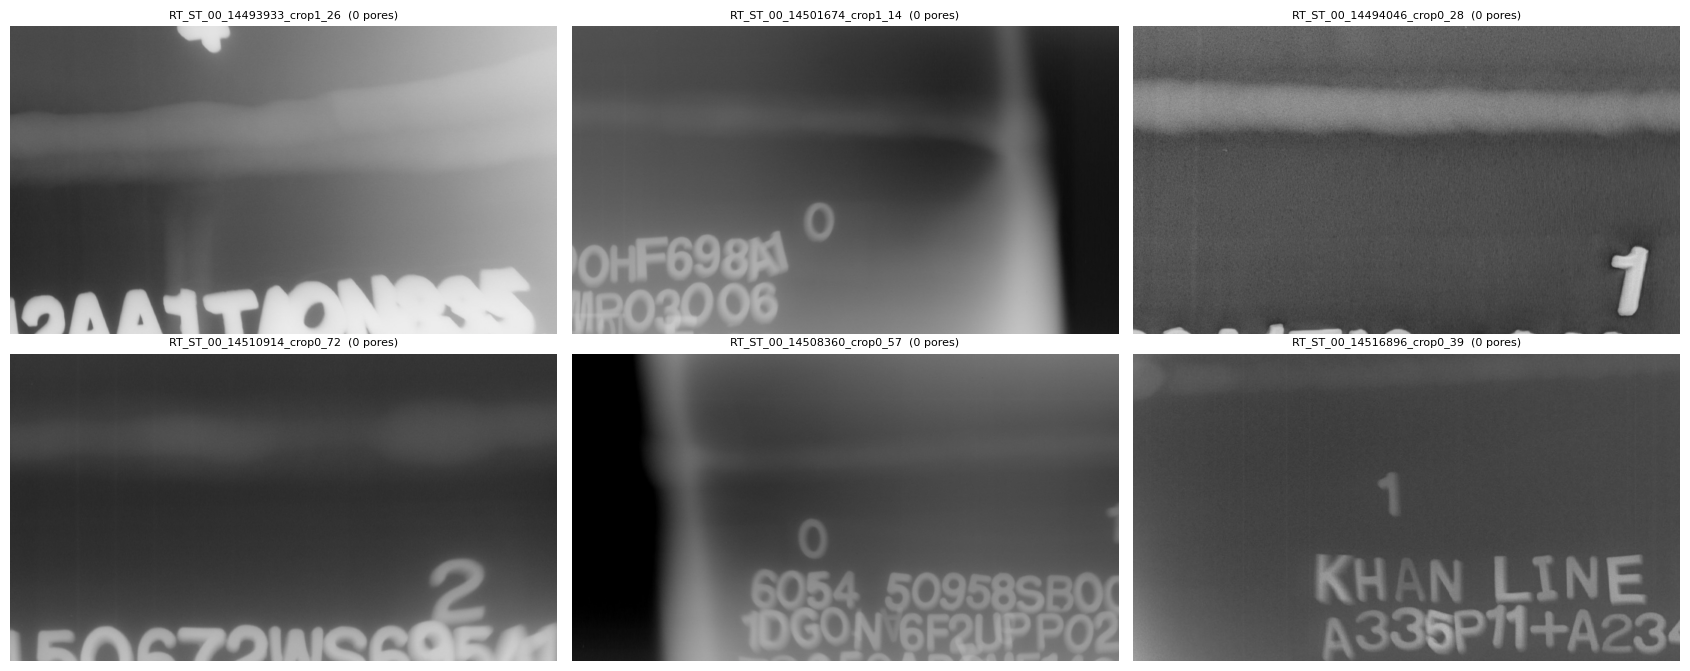

In [12]:
# 음성 샘플(정상 타일 + 파노 크롭)도 확인 — 폴리곤이 하나도 없어야 정상
show_labels("train", 6, positives=False)

## 5. 학습

설정 근거:
- **`imgsz=1280`**: 이미지가 1280×720 네이티브. 기공은 수십 픽셀 수준이라 640으로 줄이면 작은 기공이 소실된다. VRAM이 부족하면 `batch`를 4 또는 2로 내리지 `imgsz`를 먼저 줄이지 말 것.
- **`hsv_h=0, hsv_s=0`**: RT 필름은 사실상 그레이스케일. 색상 증강은 무의미하고 해롭다. 밝기(`hsv_v`)만 필름 농도 편차 모사용으로 남긴다.
- **`degrees=3`**: 필름은 수평 정렬되어 촬영된다. 큰 회전은 분포 밖 데이터를 만든다.
- **`copy_paste=0`**: seg에서 유용하지만, 배경(빈 라벨) 이미지가 절반인 구성에서는 붙여넣기가 배경 이미지를 오염시킬 위험이 있다.
- **`close_mosaic=10`**: 마지막 10에폭은 모자이크를 꺼서 실제 추론 분포에 맞춘다.

In [9]:
import subprocess, sys

r = subprocess.run(
    [sys.executable, "-c",
     "import os; os.environ['KMP_DUPLICATE_LIB_OK']='TRUE'; "
     "import torch, ultralytics; print('OK', torch.__version__, torch.cuda.is_available())"],
    capture_output=True, text=True
)
print("STDOUT:", r.stdout)
print("STDERR:", r.stderr[-500:] if r.stderr else "")
print("returncode:", r.returncode)

STDOUT: OK 2.12.1+cu130 True

STDERR: 
returncode: 0


In [10]:
import subprocess
import sys
import re

cmd = [sys.executable, "-u", r"C:\Users\user\weldscan\weldscan_porosity\train_porosity.py", "--quick"]

proc = subprocess.Popen(
    cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, encoding="utf-8", errors="replace", bufsize=1
)

# YOLO tqdm 진행바에 포함되는 특수 패턴 감지
progress_pattern = re.compile(r'[━─╸]|it/s|s<|\d+/\d+\s+\d+%')

for line in proc.stdout:
    line_str = line.strip()
    if not line_str:
        continue
    
    # 중간 배치 진행바 출력은 출력하지 않고 스킵
    if progress_pattern.search(line_str):
        continue
        
    # 주요 메타 정보 및 에폭 관련 핵심 출력만 표시
    print(line_str)

proc.wait()
print("\n종료 코드:", proc.returncode)

[autoreload of porosity.config failed: Traceback (most recent call last):
  File "C:\Users\user\anaconda3\Lib\site-packages\IPython\extensions\autoreload.py", line 322, in check
    elif self.deduper_reloader.maybe_reload_module(m):
         ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^
  File "C:\Users\user\anaconda3\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 545, in maybe_reload_module
    new_source_code = f.read()
UnicodeDecodeError: 'cp949' codec can't decode byte 0xed in position 50: illegal multibyte sequence
]
[autoreload of porosity.data_prep failed: Traceback (most recent call last):
  File "C:\Users\user\anaconda3\Lib\site-packages\IPython\extensions\autoreload.py", line 322, in check
    elif self.deduper_reloader.maybe_reload_module(m):
         ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^
  File "C:\Users\user\anaconda3\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 545, in maybe_reload_module
    new_source_code 

[quick] train: 양성 300 + 음성 300 = 600장
[quick] val: 양성 60 + 음성 60 = 120장
[train_porosity] QUICK 모드: model=yolov8n-seg.pt epochs=8 data=C:\Users\user\weldscan\work\yolo_porosity_quick\dataset.yaml (양성/음성 균형 서브셋, 정확도는 참고 금지)
[train_porosity] model=yolov8n-seg.pt imgsz=1280 batch=8 workers=4 device=0 epochs=8 data=C:\Users\user\weldscan\work\yolo_porosity_quick\dataset.yaml
Ultralytics 8.4.147  Python-3.13.9 torch-2.12.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070, 12227MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\user\weldscan\work\yolo_porosity_quick\dataset.yaml, degrees=3.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dy

In [11]:
import subprocess
import sys
import re

cmd = [sys.executable, "-u", r"C:\Users\user\weldscan\weldscan_porosity\train_porosity.py", "--demo"]

proc = subprocess.Popen(
    cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, encoding="utf-8", errors="replace", bufsize=1
)

# YOLO tqdm 진행바에 포함되는 특수 패턴 감지
progress_pattern = re.compile(r'[━─╸]|it/s|s<|\d+/\d+\s+\d+%')

for line in proc.stdout:
    line_str = line.strip()
    if not line_str:
        continue

    # 중간 배치 진행바 출력은 출력하지 않고 스킵
    if progress_pattern.search(line_str):
        continue

    # 주요 메타 정보 및 에폭 관련 핵심 출력만 표시
    print(line_str)

proc.wait()
print("\n종료 코드:", proc.returncode)

[autoreload of porosity.config failed: Traceback (most recent call last):
  File "C:\Users\user\anaconda3\Lib\site-packages\IPython\extensions\autoreload.py", line 322, in check
    elif self.deduper_reloader.maybe_reload_module(m):
         ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^
  File "C:\Users\user\anaconda3\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 545, in maybe_reload_module
    new_source_code = f.read()
UnicodeDecodeError: 'cp949' codec can't decode byte 0xed in position 50: illegal multibyte sequence
]
[autoreload of porosity.data_prep failed: Traceback (most recent call last):
  File "C:\Users\user\anaconda3\Lib\site-packages\IPython\extensions\autoreload.py", line 322, in check
    elif self.deduper_reloader.maybe_reload_module(m):
         ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^
  File "C:\Users\user\anaconda3\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 545, in maybe_reload_module
    new_source_code 

[demo] train: 양성 4000 + 음성 4000 = 8000장
[demo] val: 양성 600 + 음성 600 = 1200장
[train_porosity] DEMO 모드: model=yolov8s-seg.pt epochs=25 data=C:\Users\user\weldscan\work\yolo_porosity_demo\dataset.yaml
[train_porosity] model=yolov8s-seg.pt imgsz=1280 batch=8 workers=4 device=0 epochs=25 data=C:\Users\user\weldscan\work\yolo_porosity_demo\dataset.yaml
Ultralytics 8.4.147  Python-3.13.9 torch-2.12.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070, 12227MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\user\weldscan\work\yolo_porosity_demo\dataset.yaml, degrees=3.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, 

## 6. 인스턴스 단위 평가 (mAP)

여기 수치는 "기공을 픽셀 단위로 얼마나 잘 그리는가"다. 대시보드 판정 성능과는 다른 지표이므로
7단계를 반드시 이어서 수행한다.

In [4]:
import json
from pathlib import Path
from ultralytics import YOLO

info = json.loads((cfg.PATHS.work_root / "last_train_run_demo.json").read_text(encoding="utf-8"))
best_pt = Path(info["best_pt"])
run_dir = Path(info["run_dir"])

import yaml
train_args = yaml.safe_load((run_dir / "args.yaml").read_text(encoding="utf-8"))

best = YOLO(str(best_pt))

m = best.val(data=str(cfg.PATHS.dataset_yaml), imgsz=train_args["imgsz"],
             batch=train_args["batch"], device=cfg.TRAIN.device, split="val",
             workers=0,
             plots=True, verbose=False)

summary = pd.DataFrame([{
    "box_mAP50":  float(m.box.map50), "box_mAP50-95": float(m.box.map),
    "mask_mAP50": float(m.seg.map50), "mask_mAP50-95": float(m.seg.map),
    "precision":  float(m.box.mp),    "recall":        float(m.box.mr),
}])
display(summary.round(4).T.rename(columns={0: "value"}))

Ultralytics 8.4.147  Python-3.13.9 torch-2.12.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070, 12227MiB)
YOLOv8s-seg summary (fused): 85 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 262.3245.7 MB/s, size: 55.6 KB)
val: Scanning C:\Users\user\weldscan\work\yolo_porosity\labels\val.cache... 5350 images, 2675 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5350/5350 42.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 669/669 7.9it/s 1:240.1sss
                   all       5350       9831      0.447      0.408       0.37      0.131      0.449      0.401      0.363      0.118
Speed: 0.3ms preprocess, 6.8ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to C:\Users\user\weldscan\weldscan_porosity\notebooks\runs\segment\val-2


,value
box_mAP50,0.3702
box_mAP50-95,0.1310
mask_mAP50,0.3630
mask_mAP50-95,0.1182
precision,0.4473
recall,0.4084


## 7. 이미지 단위 정상/이상 판정 임계값 튜닝 ← **대시보드가 실제로 쓰는 부분**

절차:
1. val 전체를 낮은 conf(0.15)로 추론해 인스턴스 후보를 모은다
2. 이미지 점수 = max(instance conf)
3. val을 `stem` 해시로 tune/test 절반씩 **결정적 분할**
4. tune 쪽에서만 임계값을 고르고, test 쪽에서만 최종 수치를 보고한다
   (같은 데이터로 튜닝하고 보고하면 낙관 편향이 생긴다)

임계값 선택 규칙은 **recall 우선**이다. 용접 검사에서 미검출(FN)은 리젝 누락으로 이어지고,
오검출(FP)은 검사자가 한 번 더 보는 비용에 그친다. 비대칭 손실이므로 recall 하한을 먼저 걸고
그 안에서 FP를 최소화한다.

In [18]:
mf_val = pd.read_csv(cfg.PATHS.yolo_root / "manifest_val.csv")
val_img_dir = cfg.PATHS.yolo_root / "images" / "val"

cfg.INFER.imgsz = train_args["imgsz"]
scores = E.score_images(best, mf_val, val_img_dir, cfg.INFER,
                        batch=train_args["batch"])
scores = E.split_tune_test(scores, seed=cfg.DATA.seed)

scoring:   0%|          | 0/669 [00:00<?, ?it/s]

In [17]:
import inspect
print(inspect.getsource(E.sweep))

def sweep(scores: pd.DataFrame, min_instances: int = 1,
          grid: np.ndarray | None = None, min_thr: float | None = None) -> pd.DataFrame:
    """
    임계값별 이미지 단위 지표.
    판정 규칙: conf >= thr 인 인스턴스가 min_instances개 이상 -> '이상'

    min_thr: 그리드 하한. None이면 scores에 실제로 존재하는 최소 confidence값을
        자동으로 사용한다. score_images()가 이미 conf=cfg.INFER.conf 이상만
        수집했으므로, 그보다 낮은 임계값은 결과가 전부 동일한(평평한) 구간이라
        의미가 없다 - 잘못하면 그 평평한 구간에서 동점 처리로 conf 미만의
        비현실적인 decision_conf가 뽑혀 PorosityDetector 로딩 시 거부당한다.
    """
    if min_thr is None:
        all_confs = [c for cl in scores["conf_list"] for c in cl]
        min_thr = min(all_confs) if all_confs else 0.05
    if grid is None:
        grid = np.round(np.arange(max(0.01, min_thr), 0.951, 0.01), 3)

    y = scores["label"].to_numpy().astype(int)
    conf_lists = scores["conf_list"].tolist()

    rows = []
    for thr in grid:
        pred = np.array(
            [1 if sum(c >= thr for c in cl) >= min_instances else 0 for cl in conf_lis

In [20]:
print("cfg.INFER.conf =", cfg.INFER.conf)

all_confs = [c for cl in tune["conf_list"] for c in cl]
print("tune 전체 conf 개수:", len(all_confs))
print("tune conf 최솟값:", min(all_confs) if all_confs else "없음(전부 빈 리스트)")
print("tune conf_list 길이 분포:")
print(tune["conf_list"].apply(len).describe())

import inspect
sig = inspect.signature(E.sweep)
print("\nsweep 함수 시그니처:", sig)

cfg.INFER.conf = 0.15
tune 전체 conf 개수: 3824
tune conf 최솟값: 0.15002907812595367
tune conf_list 길이 분포:
count    2691.000000
mean        1.421033
std         2.831446
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max        31.000000
Name: conf_list, dtype: float64

sweep 함수 시그니처: (scores: 'pd.DataFrame', min_instances: 'int' = 1, grid: 'np.ndarray | None' = None) -> 'pd.DataFrame'


In [21]:
import importlib
import porosity.evaluate
importlib.reload(porosity.evaluate)
from porosity import evaluate as E

import inspect
print(inspect.signature(E.sweep))

(scores: 'pd.DataFrame', min_instances: 'int' = 1, grid: 'np.ndarray | None' = None, min_thr: 'float | None' = None) -> 'pd.DataFrame'


선택 규칙: recall 하한 미달 -> F1 최대점 폴백
선택 임계값: 0.150  (tune: recall=0.8295 precision=0.9564 fpr=0.0380)


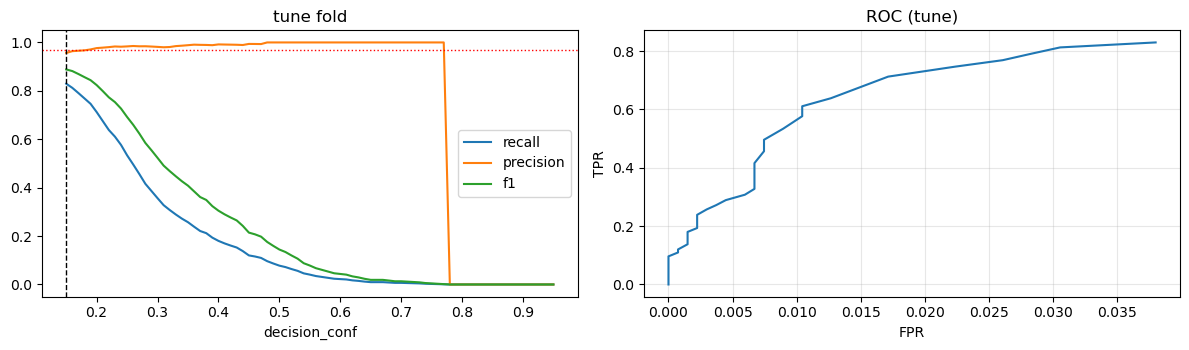

=== held-out(test fold) 최종 성능 ===
  recall         0.8296
  precision      0.9700
  specificity    0.9745
  f1             0.8943
  accuracy       0.9022
  balanced_acc   0.9020

  혼동행렬  TP=1100  FP=34  FN=226  TN=1299


,n,fp,fpr
source,,,
crop,1222,4,0.0033
tile,111,30,0.2703


In [22]:
import matplotlib.pyplot as plt

MIN_RECALL = 0.97

tune = scores[scores.fold == "tune"]
test = scores[scores.fold == "test"]

sw = E.sweep(tune, min_instances=cfg.INFER.min_instances)
op = E.pick_operating_point(sw, min_recall=MIN_RECALL)
print("선택 규칙:", op["rule"])
print(f"선택 임계값: {op['thr']:.3f}  (tune: recall={op['recall']:.4f} "
      f"precision={op['precision']:.4f} fpr={op['fpr']:.4f})")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].plot(sw.thr, sw.recall, label="recall")
ax[0].plot(sw.thr, sw.precision, label="precision")
ax[0].plot(sw.thr, sw.f1, label="f1")
ax[0].axvline(op["thr"], color="k", ls="--", lw=1)
ax[0].axhline(MIN_RECALL, color="r", ls=":", lw=1)
ax[0].set_xlabel("decision_conf"); ax[0].legend(); ax[0].set_title("tune fold")
ax[1].plot(sw.fpr, sw.recall); ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR")
ax[1].set_title("ROC (tune)"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

held = E.evaluate_at(test, op["thr"], cfg.INFER.min_instances)
print("=== held-out(test fold) 최종 성능 ===")
for k in ["recall", "precision", "specificity", "f1", "accuracy", "balanced_acc"]:
    print(f"  {k:14s} {held[k]:.4f}")
print(f"\n  혼동행렬  TP={held['tp']:.0f}  FP={held['fp']:.0f}  "
      f"FN={held['fn']:.0f}  TN={held['tn']:.0f}")

neg = test[test.label == 0].copy()
neg["pred"] = (neg["conf_list"].apply(lambda c: sum(x >= op["thr"] for x in c))
               >= cfg.INFER.min_instances).astype(int)
display(neg.groupby("source")["pred"].agg(n="size", fp="sum")
           .assign(fpr=lambda d: (d.fp / d.n).round(4)))

In [23]:
held = E.evaluate_at(test, op["thr"], cfg.INFER.min_instances)
print("=== held-out(test fold) 최종 성능 ===")
for k in ["recall", "precision", "specificity", "f1", "accuracy", "balanced_acc"]:
    print(f"  {k:14s} {held[k]:.4f}")
print(f"\n  혼동행렬  TP={held['tp']:.0f}  FP={held['fp']:.0f}  "
      f"FN={held['fn']:.0f}  TN={held['tn']:.0f}")

# 음성 소스별 FPR — 크롭 음성에서만 FP가 튀면 크롭 품질 문제를 의심해야 한다
neg = test[test.label == 0].copy()
neg["pred"] = (neg["conf_list"].apply(lambda c: sum(x >= op["thr"] for x in c))
               >= cfg.INFER.min_instances).astype(int)
display(neg.groupby("source")["pred"].agg(n="size", fp="sum")
           .assign(fpr=lambda d: (d.fp / d.n).round(4)))

=== held-out(test fold) 최종 성능 ===
  recall         0.8296
  precision      0.9700
  specificity    0.9745
  f1             0.8943
  accuracy       0.9022
  balanced_acc   0.9020

  혼동행렬  TP=1100  FP=34  FN=226  TN=1299


,n,fp,fpr
source,,,
crop,1222,4,0.0033
tile,111,30,0.2703


## 8. 배포 아티팩트 & 계약 테스트

`artifacts/porosity_yolov8seg/` 에 **best.pt + thresholds.json + model_config.json**을 떨군다.
대시보드 쪽은 이 폴더 경로만 알면 된다.

In [24]:
import shutil

# df가 세션에 없을 수 있으니 방어적으로 다시 로드 (재빌드 아님, CSV만 읽음 - 몇 초)
if "df" not in dir():
    df = D.load_metadata()

A = cfg.PATHS.artifacts_dir
A.mkdir(parents=True, exist_ok=True)

shutil.copy2(best_pt, A / "best.pt")
E.save_thresholds(A / "thresholds.json", op["thr"],
                  cfg.INFER.min_instances, held, cfg.INFER)
(A / "model_config.json").write_text(json.dumps({
    "schema_version": cfg.SCHEMA_VERSION,
    "model_name": train_args["model"].replace(".pt", ""),
    "class_names": cfg.CLASS_NAMES,
    "tile": [cfg.TILE_W, cfg.TILE_H],
    "train_run": str(run_dir),
    "train_config_used": {k: train_args[k] for k in
        ("model", "epochs", "imgsz", "batch", "data") if k in train_args},
    "instance_metrics": summary.round(5).to_dict("records")[0],
    "image_level_metrics_heldout": held,
    "build": cfg.snapshot(),
}, ensure_ascii=False, indent=2), encoding="utf-8")

print(*[p.name for p in sorted(A.iterdir())], sep="\n")

# --- 계약 테스트: 다른 팀원이 쓰는 방식 그대로 호출해본다 ---
from porosity.detector import PorosityDetector

det = PorosityDetector.from_artifacts(A, device=cfg.TRAIN.device)

sample_pos = mf_val[mf_val.label == 1].iloc[0]["stem"]
sample_neg = mf_val[mf_val.label == 0].iloc[0]["stem"]

for stem in (sample_pos, sample_neg):
    out = det.predict(val_img_dir / f"{stem}.jpg", pixel_spacing_mm=0.1)
    print(f"\n{stem}  ->  verdict={out['verdict']}  score={out['score']:.3f}  "
          f"n={out['n_instances']}  {out['timing_ms']:.0f}ms")
    if out["instances"]:
        ins = out["instances"][0]
        print("   첫 인스턴스:", {k: ins[k] for k in
              ["conf", "area_px", "equivalent_diameter_px", "equivalent_diameter_mm"]})

REQUIRED = {"schema_version", "model", "image", "verdict", "defect_type", "score",
            "n_instances", "total_area_px", "total_area_ratio", "instances",
            "timing_ms", "warnings"}
out = det.predict(val_img_dir / f"{sample_pos}.jpg", pixel_spacing_mm=0.1)
assert REQUIRED <= set(out), f"스키마 누락: {REQUIRED - set(out)}"
assert out["verdict"] in {"normal", "abnormal"}
json.dumps(out)
print("\n계약 스키마 v%s OK" % out["schema_version"])

pano = df[(df["annotation_case"] == "normal") & (~df["is_tile"]) & (df["croppable"])].iloc[0]
out = det.tile_predict(cfg.PATHS.raw_root / pano.image_path,
                       overlap=0.2, pixel_spacing_mm=0.1)
print(f"{pano.width}x{pano.height} -> verdict={out['verdict']} "
      f"n={out['n_instances']} {out['timing_ms']:.0f}ms")
print("warnings:", out["warnings"])

best.pt
model_config.json
thresholds.json

RT_ST_02_14519767  ->  verdict=abnormal  score=0.180  n=1  107ms
   첫 인스턴스: {'conf': 0.17970509827136993, 'area_px': 1770.5, 'equivalent_diameter_px': 47.479, 'equivalent_diameter_mm': 4.7479}

RT_ST_00_14520684  ->  verdict=normal  score=0.000  n=0  11ms

계약 스키마 v1.0 OK
3481x943 -> verdict=normal n=0 112ms
warnings: ['tiled inference: 타일 경계 중복 인스턴스 미제거']


## 9. 인계 메모

### git 병합 구조
```
weldscan/
├── src/porosity/            # ← 이 패키지를 그대로 올린다
│   ├── config.py            #   경로/하이퍼파라미터 단일 소스
│   ├── label_io.py          #   라벨 JSON 파서
│   ├── data_prep.py         #   데이터셋 빌더
│   ├── evaluate.py          #   임계값 튜닝
│   └── detector.py          #   ★ 대시보드가 쓰는 유일한 진입점
├── notebooks/porosity_yolov8seg.ipynb
└── artifacts/porosity_yolov8seg/   # best.pt는 Git LFS 또는 릴리스 첨부
```
`artifacts/`와 `work/`는 `.gitignore`에. `best.pt`는 수십 MB라 LFS 없이 올리면 리포가 망가진다.

### 백엔드 쪽에 전달할 인터페이스
```python
from porosity.detector import PorosityDetector
det = PorosityDetector.from_artifacts("artifacts/porosity_yolov8seg")   # 프로세스당 1회
out = det.predict(image_path, pixel_spacing_mm=0.1)                     # 요청당 1회
```
반환 스키마는 `detector.py` 상단 docstring에 고정되어 있고 `schema_version`으로 버전이 박힌다.
`thresholds.json`의 `schema_version`이 코드와 다르면 로드 시점에 예외가 난다 — 조용한 오동작 대신 즉시 실패.

### 다른 파트가 이어받을 지점
- **룰엔진(KS B 0845)**: `instances[].equivalent_diameter_mm`, `n_instances`, `total_area_ratio`를 입력으로 등급 판정.
  단 **`pixel_spacing_mm`은 메타데이터에 없다.** RT 필름의 픽셀-mm 환산 계수를 어디서 받을지 결정해야 mm 기반 등급 판정이 가능하다. 없으면 px 기준 상대 지표만 쓸 수 있다.
- **유사사례 매칭**: 필요하면 임베딩 추출 함수를 추가로 뽑아준다 (YOLO 백본 특징 또는 별도 인코더).
- **선박종류·작업부위**: `metadata.csv`에 해당 컬럼이 없다(`type`/`material`은 전부 RT/ST 단일값). 파이프라인 ②③단계에 필요한 정보이므로 이미지 DB 담당과 별도 협의 필요.

### 남아있는 한계 (평가 때 질문받을 수 있는 것)
1. **train/val 출처 누수 가능성** — 같은 원본 필름에서 잘린 타일이 train과 val에 나뉘어 들어갔을 수 있다. `metadata.csv`에 원본 필름 ID가 없어 통제 불가. 실제 성능은 여기 수치보다 낮을 수 있다.
2. **음성 크롭의 라벨 신뢰도** — 정상 파노라마에 라벨되지 않은 미세 기공이 있으면 FP처럼 보이는 정답을 만든다.
3. **단일 결함 타입** — 기공만 학습했으므로 균열/융합불량/슬래그혼입 이미지를 넣으면 '정상'으로 나온다. 멀티클래스 확장은 `CLASS_NAMES`와 `POROSITY_ALIASES`를 일반화하면 된다.
